# P4: Prediction levels

This protocol covers the three prediction tasks and levels (residue, domain, protein) and how each one shapes `df_parts`. Before you can ask CPP *which physicochemical features separate your groups*, you first have to decide **what one example is**. Is it a single residue (a cleavage site, a post-translational modification), one sub-region of a protein (a transmembrane domain), or a whole chain (a short peptide)? That choice is the **prediction level**, and in AAanalysis it is written directly into the `load_dataset` name prefix: `AA_*` (residue), `DOM_*` (domain), `SEQ_*` (protein). The level is *not* a different algorithm: all three feed the **same** `CPP.run`. What changes is the **unit of comparison**, and therefore how you build `df_parts`.

Choosing the prediction level fixes the **unit of comparison** (a **window** at residue level, a **part** set at domain level, or the **whole chain** at protein level), and that, in turn, fixes how the parts are *named* and which *kind* of feature you can read out. Pick the level from your biological question first; the `df_parts` construction then follows mechanically.

Like Protocol 1, this is a determinant-discovery / prediction setup: you contrast a **test group** (`label=1`) against a **reference group** (`label=0`) and read out the **signature**, the set of position-resolved physicochemical features that separates them. Getting `df_parts` right is the single most common bottleneck for new users, so this protocol shows the correct construction side by side for all three levels.

**When to use it.** Use this protocol when you have a labelled two-group task and are unsure whether it is **residue**, **domain**, or **protein** level (or when you are building `df_parts` for the first time and want a correct template per level). The level follows the biological question:

- **Residue level** (`AA_*`): *"What distinguishes a position from its neighbours?"* The **unit of comparison** is a fixed-length **window** anchored at a residue or a scissile bond (e.g. protease cleavage, PTM sites).
- **Domain level** (`DOM_*`): *"What distinguishes one sub-region of a protein from the same region in another protein?"* The unit is a **part** set derived from `tmd_start` / `tmd_stop` (e.g. gamma-secretase substrates compared over their transmembrane domain), CPP's native ground.
- **Protein level** (`SEQ_*`): *"What distinguishes one whole chain from another?"* The unit is the **whole sequence** as a single part (e.g. aggregation-prone vs. soluble peptides).

**When *not* to use it.** This protocol is about *choosing* a level and wiring `df_parts`: it is not where you *sample* a reference group. If your residue-level task has no ready-made negatives (true for most protease / PTM problems), you must first construct non-site windows; see the *Next step*. And if you have only one group, or want to *redesign* a sequence rather than contrast two sets, you are outside the determinant-discovery setup this protocol assumes.

**Input.** A `df_seq` whose format matches the level (see `SequenceFeature.get_df_parts`), plus a binary `label` column (`1` = test group, `0` = reference group). Remember that `load_dataset(name=..., n=N)` returns `2N` rows (N per group); read group sizes from the `label` column, never from `len(df_seq)`. The level is encoded in the dataset name prefix (`AA_*` / `DOM_*` / `SEQ_*`; see the data-loader tutorial for the full naming scheme).

| Level | Dataset | `df_seq` format | Biological contrast (test=1 vs reference=0) |
| --- | --- | --- | --- |
| residue | `AA_CASPASE3` | **sequence-based** (9-residue windows around the scissile bond; even window = between-residues) | cleaved (`1`) vs. not cleaved (`0`) |
| domain | `DOM_GSEC` | **position-based** (`tmd_start` / `tmd_stop`, 1-based inclusive) | gamma-secretase substrate (`1`) vs. non-substrate (`0`) |
| protein | `SEQ_AMYLO` | **sequence-based** (short full peptides) | aggregation-prone (`1`) vs. soluble (`0`) |

These tables come from upstream. Domain- and protein-level tables are loaded directly with `load_dataset` (or your own annotation), while residue-level windows are produced by the *Construct sets & sampling* protocol (`AAWindowSampler`), which is also where you build the reference group when no negatives exist.

In [1]:
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

sf = aa.SequenceFeature()

**Run.** The pipeline is identical at every level (`get_df_parts` -> `CPP.run` -> `TreeModel` ranking), and only `df_parts` (and the matching `split_kws`) differ. We build the three `df_parts` first, then run CPP on each.

**Residue level: a window as a single part.** The 9-residue window *is* the unit of comparison, so we map the **whole window onto one part**. We set `jmd_n_len=0` / `jmd_c_len=0` so no flanking is split off, and select the single neutral part `tmd`, here just a placeholder name for "the window", not a transmembrane domain. (At the residue level the principled naming follows the Schechter-Berger `... P2 . P1 | P1' . P2' ...` convention around the scissile bond; today parts are chosen from the predefined family, so we keep the neutral `tmd`.)

In [2]:
df_res = aa.load_dataset(name="AA_CASPASE3", n=15)
labels_res = df_res["label"].to_list()

df_parts_res = sf.get_df_parts(df_seq=df_res, list_parts=["tmd"], jmd_n_len=0, jmd_c_len=0)
aa.display_df(df=df_parts_res, n_rows=5)

,tmd
entry,
CASPASE3_1_pos126,QTLRDSMLK
CASPASE3_1_pos127,TLRDSMLKY
CASPASE3_2_pos116,VDETDSGAG
CASPASE3_2_pos117,DETDSGAGL
CASPASE3_2_pos223,VDAVDTGIS


**Domain level: named parts from `tmd_start` / `tmd_stop`.** The position-based format lets `get_df_parts` slice each sequence into the **named parts** `jmd_n` / `tmd` / `jmd_c` (here the TMD *is* the domain of interest). `jmd_n_len` / `jmd_c_len` set how many flanking residues frame the domain.

In [3]:
df_dom = aa.load_dataset(name="DOM_GSEC", n=15)
labels_dom = df_dom["label"].to_list()

df_parts_dom = sf.get_df_parts(df_seq=df_dom, list_parts=["jmd_n", "tmd", "jmd_c"],
                               jmd_n_len=10, jmd_c_len=10)
aa.display_df(df=df_parts_dom, n_rows=5)

,jmd_n,tmd,jmd_c
entry,,,
Q14802,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
Q86UE4,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
Q969W9,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
P53801,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
Q8IUW5,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


**Protein level: the whole chain as a single part.** For whole-chain prediction the entire sequence is the part. As at the residue level we set `jmd_n_len=0` / `jmd_c_len=0` and select the single neutral part `tmd`, but here it spans the full peptide, not a window.

In [4]:
df_prot = aa.load_dataset(name="SEQ_AMYLO", n=15)
labels_prot = df_prot["label"].to_list()

df_parts_prot = sf.get_df_parts(df_seq=df_prot, list_parts=["tmd"], jmd_n_len=0, jmd_c_len=0)
aa.display_df(df=df_parts_prot, n_rows=5)

,tmd
entry,
AMYLO_1,AAAQAA
AMYLO_2,QSSYSS
AMYLO_3,QSYGQQ
AMYLO_4,QSYNPP
AMYLO_5,QSYSGY


**Run CPP per level.** `split_kws` must fit the part lengths (segments/patterns cannot exceed the shortest part). For the short residue window we use small **positional** splits; for the domain we size splits to the 10-residue JMDs; for the protein we use a single **compositional** `Segment(1,1)` whole-part average (position-agnostic, composition-like).

Notice how the only thing that changes between the three runs is `df_parts` (and the `split_kws` sized to it): the `CPP.run` -> `TreeModel` half is copy-paste identical at every level. To keep the focus on the figure we show only the domain-level `df_feat` here, and visualise that same signature as a **feature map** in the *Output* section just below.

In [5]:
# Residue level: positional splits over the short window
split_kws_res = sf.get_split_kws(split_types=["Segment", "Pattern"], n_split_min=1,
                                 n_split_max=4, steps_pattern=[1, 2], n_min=2, n_max=3, len_max=9)
cpp = aa.CPP(df_parts=df_parts_res, split_kws=split_kws_res)
df_feat_res = cpp.run(labels=labels_res, n_filter=20, n_jobs=1)  # n_jobs=1 avoids a spawn issue on Python 3.14/macOS

X_res = sf.feature_matrix(features=df_feat_res["feature"], df_parts=df_parts_res)
tm = aa.TreeModel().fit(X_res, labels=labels_res)
df_feat_res = tm.add_feat_importance(df_feat=df_feat_res)

In [6]:
# Domain level: splits sized to the named parts (positional + compositional)
split_kws_dom = sf.get_split_kws(n_split_min=1, n_split_max=10, steps_pattern=[3, 4],
                                 n_min=2, n_max=4, len_max=10)
cpp = aa.CPP(df_parts=df_parts_dom, split_kws=split_kws_dom)
df_feat_dom = cpp.run(labels=labels_dom, n_filter=20, n_jobs=1)  # n_jobs=1 avoids a spawn issue on Python 3.14/macOS

X_dom = sf.feature_matrix(features=df_feat_dom["feature"], df_parts=df_parts_dom)
tm = aa.TreeModel().fit(X_dom, labels=labels_dom)
df_feat_dom = tm.add_feat_importance(df_feat=df_feat_dom)
aa.display_df(df=df_feat_dom[["feature", "mean_dif", "abs_auc", "feat_importance"]], n_rows=5)

,feature,mean_dif,abs_auc,feat_importance
1,"TMD-Pattern(C,4,8)-ROBB760103",0.176000,0.467000,8.380000
2,"TMD-Pattern(C,4,8)-MUNV940101",-0.134000,0.456000,6.685000
3,"TMD-Pattern(C,4,8)-RACS820114",-0.191000,0.440000,6.238000
4,"TMD-Pattern(C,4,8)-RACS820113",-0.262000,0.436000,4.690000
5,"TMD-Pattern(C,4,8)-NAGK730103",-0.282000,0.431000,5.885000


In [7]:
# Protein level: compositional Segment(1,1) over the whole chain
split_kws_prot = sf.get_split_kws(split_types="Segment", n_split_min=1, n_split_max=1)
cpp = aa.CPP(df_parts=df_parts_prot, split_kws=split_kws_prot)
df_feat_prot = cpp.run(labels=labels_prot, n_filter=15, n_jobs=1)  # n_jobs=1 avoids a spawn issue on Python 3.14/macOS

X_prot = sf.feature_matrix(features=df_feat_prot["feature"], df_parts=df_parts_prot)
tm = aa.TreeModel().fit(X_prot, labels=labels_prot)
df_feat_prot = tm.add_feat_importance(df_feat=df_feat_prot)

**Output.** Each level returns its own `df_feat` **signature**, one row per selected feature, with the feature id reading as `Part-Split-Scale`. The downstream columns are identical across levels: `mean_dif` (signed test minus reference difference), `abs_auc` (separation strength, the adjusted AUC* in `[0, 0.5]` where `0` = no separation and `0.5` = perfect separation), and `feat_importance` (tree-based rank). The *only* thing that changes is how the feature id reads, because the parts differ; everything downstream stays the same.

> **A note on the numbers.** We deliberately use tiny `n=15`-per-group fixtures so the protocol runs in seconds. On so few sequences it is *trivial* for top-ranked features to separate the two groups perfectly, so you will see `abs_auc` sitting at or near `0.5` (especially at the residue level, where the short windows overfit most easily). Treat these values as illustrative of *what the column means*, not as a real effect size; on a full dataset the same ranking shows a graded spread of `abs_auc` below `0.5`.

The fastest way to see a signature is the **feature map** (the same plot as in *Protocol 1*). Below is the domain-level (gamma-secretase) signature: the y-axis groups features by AAontology category, the heatmap cells show `mean_dif` (red = higher in substrates, blue = higher in non-substrates), and the bars on the right show `feat_importance`.

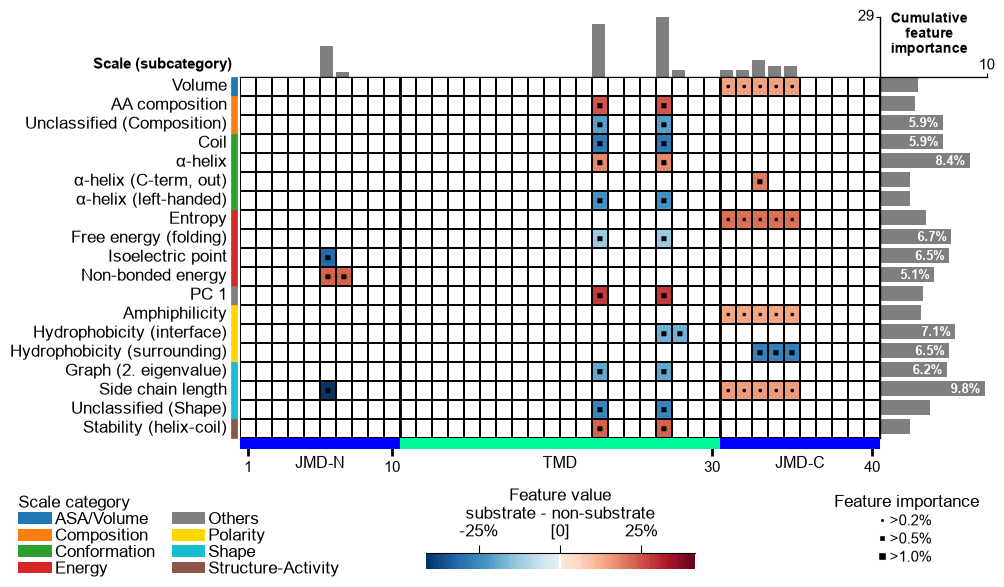

In [8]:
import matplotlib.pyplot as plt

aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot = aa.CPPPlot()                 # feature_map is an INSTANCE method
cpp_plot.feature_map(df_feat=df_feat_dom, name_test="substrate", name_ref="non-substrate")
plt.tight_layout()
plt.show()

The feature ids read differently per level because the parts differ:

| Level | `df_parts` columns | Example feature | Reads as |
| --- | --- | --- | --- |
| residue | `tmd` (the window) | `TMD-Pattern(C,5,6,8)-...` | which **positions** in the window, which property |
| domain | `jmd_n`, `tmd`, `jmd_c` | `TMD-Pattern(C,4,8)-...` | which **sub-region** of the domain, which property |
| protein | `tmd` (whole chain) | `TMD-Segment(1,1)-...` | a **whole-chain composition** property (no position) |

Visualise any level's signature with `aa.CPPPlot().feature_map(df_feat=...)` exactly as above: the plot needs the `feat_importance` column we added with `TreeModel.add_feat_importance`.

**How to interpret.** Read each output column as follows:

| Output | Non-expert reading |
| --- | --- |
| `abs_auc` (closer to `0.5`) | stronger group-separating property; `abs_auc` is the adjusted AUC* in `[0, 0.5]`, with `0` = no separation and `0.5` = perfect separation |
| positive `mean_dif` | property is **higher** in the test group (label=1) |
| negative `mean_dif` | property is **higher** in the reference group (label=0) |
| a `Segment(1,1)` feature (protein level) | a **compositional** signal (it does not depend on position) |
| a `Pattern(...)` / multi-segment feature (residue/domain) | a **positional** signal (it depends on *where* in the part) |

The level constrains the *kind* of feature you can read:

- **Residue** signatures are purely **positional**: e.g. CASPASE3 cleavage depends on which flanking position (P2, P3, P4 ...) carries which property around the scissile bond.
- **Protein** signatures are purely **compositional**: amyloid aggregation depends on overall composition, not position, so only `Segment(1,1)` features appear.
- **Domain** signatures mix both: the gamma-secretase TMD shows positional sub-region effects *and* whole-part composition.

**Key takeaways**

- The **prediction level** you pick fixes the **unit of comparison** and how parts are named: it is a modelling decision, not an algorithm switch; all three levels call the same `CPP.run`.
- The level constrains the *kind* of signature: residue is purely **positional**, protein is purely **compositional**, domain mixes both.
- Always read the **signature** (coherent blocks of related features), never a single cell, and on tiny fixtures read `abs_auc` as illustrative, not as a real effect size.

**Common mistakes.**

- **Calling `CPP(df_seq=...)`**: `CPP` takes `df_parts`; always build them with `SequenceFeature.get_df_parts` first (true at every level).
- **Forgetting that "part" means different things per level**: a window (residue), a named sub-region (domain), or the whole chain (protein). Name and interpret it accordingly.
- **Using positional splits at the protein level**: whole-chain composition is best captured by the **compositional** `Segment(1,1)`; multi-segment / `Pattern` splits over-fragment a position-agnostic signal.
- **Letting `split_kws` exceed the shortest part**: segments and patterns cannot be longer than the smallest part (e.g. a 10-residue JMD or a 9-residue window), or `CPP` raises a "too short sequences" error. Size `n_split_max` / `len_max` to the parts.
- **Confusing residue with domain**: both can use a single `tmd` part, but residue windows are short, fixed-length, and anchored at a site, while domain parts come from `tmd_start`/`tmd_stop` and carry flanking JMDs (`jmd_n_len`/`jmd_c_len`).

**Next step.** Continue with *P5: Engineer features* to turn the chosen prediction level and its `df_parts` into an engineered CPP feature set.